# 실습 1. 주민등록증 비식별화 하기 (EasyOCR)

In [37]:
import easyocr

In [38]:
# 이슈 해결
## 이슈 1: AttributeError: 'NoneType' object has no attribute 'shape'
### 이미지 경로 영어로 바꾸기
### mac, linux에서는 한글로 해도 됨

## 이슈 2: AttributeError: module 'cv2' has no attribute '__version__'
### 해결 방안: 깃허브로 설치
### uv remove easyocr
### uv add "easyocr @ git+https://github.com/JaidedAI/EasyOCR.git"

## 1. 이미지 불러오기

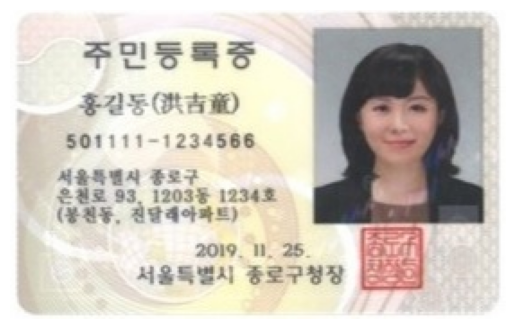

In [46]:
import matplotlib.pyplot as plt
from PIL import Image

from lib.utils.path import images_path

image_path = str(images_path() / 'id_sample.jpg')
image = Image.open(image_path)

plt.imshow(image)
plt.axis('off')
plt.show()

## 2. OCR로 텍스트 추출

In [40]:
reader = easyocr.Reader(['ko', 'en'])

In [47]:
results = reader.readtext(image)

results

[([[np.int32(37), np.int32(11)],
   [np.int32(140), np.int32(11)],
   [np.int32(140), np.int32(40)],
   [np.int32(37), np.int32(40)]],
  '주민등록증',
  np.float64(0.9990266266102005)),
 ([[np.int32(35), np.int32(43)],
   [np.int32(131), np.int32(43)],
   [np.int32(131), np.int32(63)],
   [np.int32(35), np.int32(63)]],
  '흥기동 (슴 표)',
  np.float64(0.05392104251607421)),
 ([[np.int32(29), np.int32(67)],
   [np.int32(139), np.int32(67)],
   [np.int32(139), np.int32(81)],
   [np.int32(29), np.int32(81)]],
  '50M10234566',
  np.float64(0.21267570506400582)),
 ([[np.int32(32), np.int32(84)],
   [np.int32(150), np.int32(84)],
   [np.int32(150), np.int32(114)],
   [np.int32(32), np.int32(114)]],
  '운륭 1835 1343',
  np.float64(0.013918065981910959)),
 ([[np.int32(22), np.int32(96)],
   [np.int32(116), np.int32(96)],
   [np.int32(116), np.int32(122)],
   [np.int32(22), np.int32(122)]],
  '@거 @전달?@하록',
  np.float64(0.027801202629765476)),
 ([[np.int32(101), np.int32(129)],
   [np.int32(129), np.int32(

## 이미지에 박스 그리기

c:\Workspaces\model_lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Workspaces\model_lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Workspaces\model_lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Workspaces\model_lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50669 (\N{HANGUL SYLLABLE YEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Workspaces\model_lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48744 (\N{HANGUL SYLLABLE BBAL}) missing from font(s) DejaVu Sans.
  fi

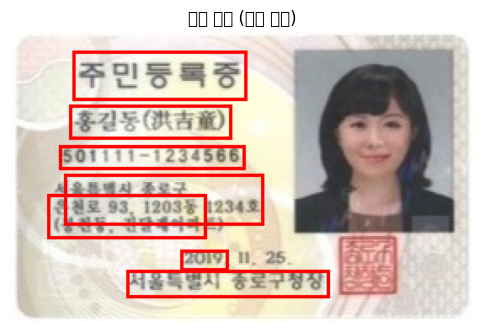

In [48]:
from PIL import ImageDraw

image_boxes = image.copy()
draw = ImageDraw.Draw(image_boxes)

for bbox, text, score in results:
    x1 = int(bbox[0][0])
    y1 = int(bbox[0][1])
    x2 = int(bbox[2][0])
    y2 = int(bbox[2][1])
    draw.rectangle([x1, y1, x2, y2], outline='red', width=2)

plt.figure(figsize=(6, 4))
plt.imshow(image_boxes)
plt.axis('off')
plt.title('인식 영역 (빨간 박스)')
plt.show()

## 3. 주민등록번호 뒷자리 검은색 박스로 채우기

In [49]:
results[3]

([[np.int32(32), np.int32(84)],
  [np.int32(150), np.int32(84)],
  [np.int32(150), np.int32(114)],
  [np.int32(32), np.int32(114)]],
 '운륭 1835 1343',
 np.float64(0.013918065981910959))

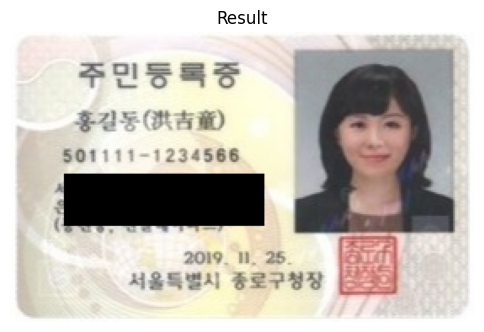

In [44]:
image_masked = image.copy()
draw = ImageDraw.Draw(image_masked)

bbox, text, score = results[3]
# 주민번호 패턴 감지: 앞 6자리 - 뒤 7자리
x1 = int(bbox[0][0])
y1 = int(bbox[0][1])
x2 = int(bbox[2][0])
y2 = int(bbox[2][1])

draw.rectangle([x1, y1, x2, y2], fill='black')

plt.figure(figsize=(6, 4))
plt.imshow(image_masked)
plt.axis('off')
plt.title('Result')
plt.show()

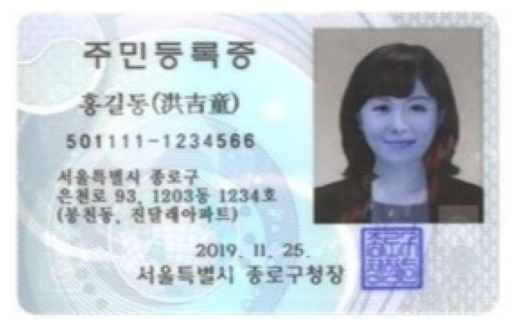

In [50]:
from easyocr.utils import reformat_input

reformat = reformat_input(image)
reformat_path = reformat_input(image_path)

plt.imshow(reformat[0])
plt.axis('off')
plt.show()

# 실습 2: 실시간 만화 번역하기 (Google Vision Cloud)

In [1]:
from google.cloud import vision

## 서비스 계정 키 등록

In [2]:
import os

from lib.utils.path import keys_path

os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = str(
    keys_path() / 'google_vision_api_key.json'
)

## 클라이언트 불러오기

In [3]:
client = vision.ImageAnnotatorClient()

## 이미지 출력하기

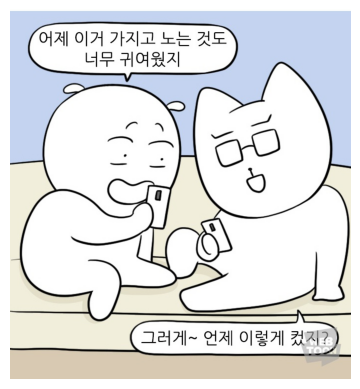

In [5]:
import matplotlib.pyplot as plt
from PIL import Image

from lib.utils.path import images_path

image_path = images_path() / 'webtoon.jpeg'

image = Image.open(image_path)

plt.imshow(image)
plt.axis('off')
plt.show()

## OCR 추출하기

In [7]:
with open(image_path, 'rb') as f:
    content = f.read()

vision_image = vision.Image(content=content)
res = client.text_detection(image=vision_image)

res

text_annotations {
  locale: "ko"
  description: "\"어제 이거 가지고 노는 것도\n너무 귀여웠지\n그러게~ 언제 이렇게 컸지?\nTOOK"
  bounding_poly {
    vertices {
      x: 49
      y: 43
    }
    vertices {
      x: 662
      y: 43
    }
    vertices {
      x: 662
      y: 702
    }
    vertices {
      x: 49
      y: 702
    }
  }
}
text_annotations {
  description: "\""
  bounding_poly {
    vertices {
      x: 49
      y: 43
    }
    vertices {
      x: 65
      y: 43
    }
    vertices {
      x: 65
      y: 76
    }
    vertices {
      x: 49
      y: 76
    }
  }
}
text_annotations {
  description: "어제"
  bounding_poly {
    vertices {
      x: 58
      y: 43
    }
    vertices {
      x: 116
      y: 43
    }
    vertices {
      x: 116
      y: 76
    }
    vertices {
      x: 58
      y: 76
    }
  }
}
text_annotations {
  description: "이거"
  bounding_poly {
    vertices {
      x: 131
      y: 43
    }
    vertices {
      x: 187
      y: 43
    }
    vertices {
      x: 187
      y: 76
    }
    vert

In [8]:
annotations = res.text_annotations

annotations

[locale: "ko"
description: "\"어제 이거 가지고 노는 것도\n너무 귀여웠지\n그러게~ 언제 이렇게 컸지?\nTOOK"
bounding_poly {
  vertices {
    x: 49
    y: 43
  }
  vertices {
    x: 662
    y: 43
  }
  vertices {
    x: 662
    y: 702
  }
  vertices {
    x: 49
    y: 702
  }
}
, description: "\""
bounding_poly {
  vertices {
    x: 49
    y: 43
  }
  vertices {
    x: 65
    y: 43
  }
  vertices {
    x: 65
    y: 76
  }
  vertices {
    x: 49
    y: 76
  }
}
, description: "어제"
bounding_poly {
  vertices {
    x: 58
    y: 43
  }
  vertices {
    x: 116
    y: 43
  }
  vertices {
    x: 116
    y: 76
  }
  vertices {
    x: 58
    y: 76
  }
}
, description: "이거"
bounding_poly {
  vertices {
    x: 131
    y: 43
  }
  vertices {
    x: 187
    y: 43
  }
  vertices {
    x: 187
    y: 76
  }
  vertices {
    x: 131
    y: 76
  }
}
, description: "가지고"
bounding_poly {
  vertices {
    x: 203
    y: 43
  }
  vertices {
    x: 294
    y: 43
  }
  vertices {
    x: 294
    y: 76
  }
  vertices {
    x: 203
    y: 76
  

In [9]:
annotations[0]

locale: "ko"
description: "\"어제 이거 가지고 노는 것도\n너무 귀여웠지\n그러게~ 언제 이렇게 컸지?\nTOOK"
bounding_poly {
  vertices {
    x: 49
    y: 43
  }
  vertices {
    x: 662
    y: 43
  }
  vertices {
    x: 662
    y: 702
  }
  vertices {
    x: 49
    y: 702
  }
}

In [10]:
annotations[1:]

[description: "\""
 bounding_poly {
   vertices {
     x: 49
     y: 43
   }
   vertices {
     x: 65
     y: 43
   }
   vertices {
     x: 65
     y: 76
   }
   vertices {
     x: 49
     y: 76
   }
 },
 description: "어제"
 bounding_poly {
   vertices {
     x: 58
     y: 43
   }
   vertices {
     x: 116
     y: 43
   }
   vertices {
     x: 116
     y: 76
   }
   vertices {
     x: 58
     y: 76
   }
 },
 description: "이거"
 bounding_poly {
   vertices {
     x: 131
     y: 43
   }
   vertices {
     x: 187
     y: 43
   }
   vertices {
     x: 187
     y: 76
   }
   vertices {
     x: 131
     y: 76
   }
 },
 description: "가지고"
 bounding_poly {
   vertices {
     x: 203
     y: 43
   }
   vertices {
     x: 294
     y: 43
   }
   vertices {
     x: 294
     y: 76
   }
   vertices {
     x: 203
     y: 76
   }
 },
 description: "노는"
 bounding_poly {
   vertices {
     x: 305
     y: 43
   }
   vertices {
     x: 366
     y: 43
   }
   vertices {
     x: 366
     y: 76
   }
   vertices

## 이미지에 박스 그리기

In [11]:
from PIL import ImageDraw

image_boxes = image.copy()
draw = ImageDraw.Draw(image_boxes)

for annot in annotations[1:]:
    v = annot.bounding_poly.vertices
    print(v)
    print('=====')
    print(v[0].x, v[0].y, '|', v[1].x, v[1].y, '|', v[2].x, v[2].y, '|', v[3].x, v[3].y)
    print('=' * 100)

    x1 = v[0].x
    y1 = v[0].y
    x2 = v[2].x
    y2 = v[2].y

    draw.rectangle([x1, y1, x2, y2], outline='red', width=2)

[x: 49
y: 43
, x: 65
y: 43
, x: 65
y: 76
, x: 49
y: 76
]
=====
49 43 | 65 43 | 65 76 | 49 76
[x: 58
y: 43
, x: 116
y: 43
, x: 116
y: 76
, x: 58
y: 76
]
=====
58 43 | 116 43 | 116 76 | 58 76
[x: 131
y: 43
, x: 187
y: 43
, x: 187
y: 76
, x: 131
y: 76
]
=====
131 43 | 187 43 | 187 76 | 131 76
[x: 203
y: 43
, x: 294
y: 43
, x: 294
y: 76
, x: 203
y: 76
]
=====
203 43 | 294 43 | 294 76 | 203 76
[x: 305
y: 43
, x: 366
y: 43
, x: 366
y: 76
, x: 305
y: 76
]
=====
305 43 | 366 43 | 366 76 | 305 76
[x: 377
y: 43
, x: 438
y: 43
, x: 438
y: 76
, x: 377
y: 76
]
=====
377 43 | 438 43 | 438 76 | 377 76
[x: 151
y: 85
, x: 211
y: 85
, x: 211
y: 117
, x: 151
y: 117
]
=====
151 85 | 211 85 | 211 117 | 151 117
[x: 221
y: 85
, x: 315
y: 85
, x: 315
y: 117
, x: 221
y: 117
]
=====
221 85 | 315 85 | 315 117 | 221 117
[x: 315
y: 85
, x: 342
y: 85
, x: 342
y: 117
, x: 315
y: 117
]
=====
315 85 | 342 85 | 342 117 | 315 117
[x: 266
y: 651
, x: 356
y: 651
, x: 356
y: 683
, x: 266
y: 683
]
=====
266 651 | 356 651 | 

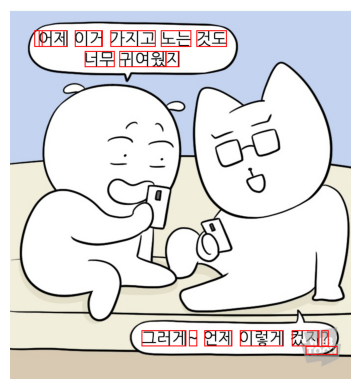

In [ ]:
plt.imshow(image_boxes)
plt.axis('off')
plt.show()

## 번역하기

In [13]:
from translate import Translator

translator = Translator(from_lang='ko', to_lang='en')

# \n 으로 나누면 말풍선 덩어리 단위로 분리됨
chunks = [
    line for line in annotations[0].description.strip().split('\n') if line.strip()
]

print('=== 원문 → 번역 ===')
translations = {}
for chunk in chunks:
    translated = translator.translate(chunk)
    translations[chunk] = translated
    print(f'{chunk}  →  {translated}')

=== 원문 → 번역 ===
"어제 이거 가지고 노는 것도  →  "Playing with this yesterday
너무 귀여웠지  →  It was so cute
그러게~ 언제 이렇게 컸지?  →  Yeah ~ When did she grow up like this?
TOOK  →  Toook


## 번역 이미지에 나타내기

In [14]:
# ── 1. annot_dict: 단어 → [x1, y1, x2, y2] ──────────────────────────
annot_dict = {}
for ann in annotations[1:]:
    v = ann.bounding_poly.vertices
    annot_dict[ann.description] = [v[0].x, v[0].y, v[2].x, v[2].y]

annot_dict

{'"': [49, 43, 65, 76],
 '어제': [58, 43, 116, 76],
 '이거': [131, 43, 187, 76],
 '가지고': [203, 43, 294, 76],
 '노는': [305, 43, 366, 76],
 '것도': [377, 43, 438, 76],
 '너무': [151, 85, 211, 117],
 '귀여웠': [221, 85, 315, 117],
 '지': [315, 85, 342, 117],
 '그러게': [266, 651, 356, 683],
 '~': [362, 651, 378, 683],
 '언제': [393, 651, 449, 683],
 '이렇게': [465, 651, 553, 683],
 '컸지': [570, 651, 625, 683],
 '?': [630, 651, 644, 683],
 'TOOK': [598, 683, 662, 700]}

In [15]:
# ── 3. chunk_data: y좌표 기준으로 덩어리 bbox 계산 ───────────────────
import re

Y_TOL = 20

chunk_data = []

for chunk in chunks:
    clean = re.sub(r'[^가-힣a-zA-Z0-9\s]', '', chunk).strip()
    words = clean.split()

    # 청크 단어와 매칭되는 annotation에서 anchor_y 잡기
    anchor_y = None
    for word in words:
        for key, coords in annot_dict.items():
            clean_key = re.sub(r'[^가-힣a-zA-Z0-9]', '', key)
            if clean_key and (word == clean_key or clean_key in word):
                anchor_y = (coords[1] + coords[3]) // 2
                break
        if anchor_y:
            break

    if anchor_y is None:
        continue

    # anchor_y 근처 같은 줄 annotation 모두 묶어 union bbox
    same_line = [
        c for c in annot_dict.values() if abs((c[1] + c[3]) // 2 - anchor_y) <= Y_TOL
    ]

    chunk_data.append(
        {
            'text': chunk,
            'translate': translations.get(chunk, ''),
            'box': [
                min(c[0] for c in same_line),
                min(c[1] for c in same_line),
                max(c[2] for c in same_line),
                max(c[3] for c in same_line),
            ],
        }
    )

chunk_data


[{'text': '"어제 이거 가지고 노는 것도',
  'translate': '"Playing with this yesterday',
  'box': [49, 43, 438, 76]},
 {'text': '너무 귀여웠지',
  'translate': 'It was so cute',
  'box': [151, 85, 342, 117]},
 {'text': '그러게~ 언제 이렇게 컸지?',
  'translate': 'Yeah ~ When did she grow up like this?',
  'box': [266, 651, 644, 683]},
 {'text': 'TOOK', 'translate': 'Toook', 'box': [598, 683, 662, 700]}]

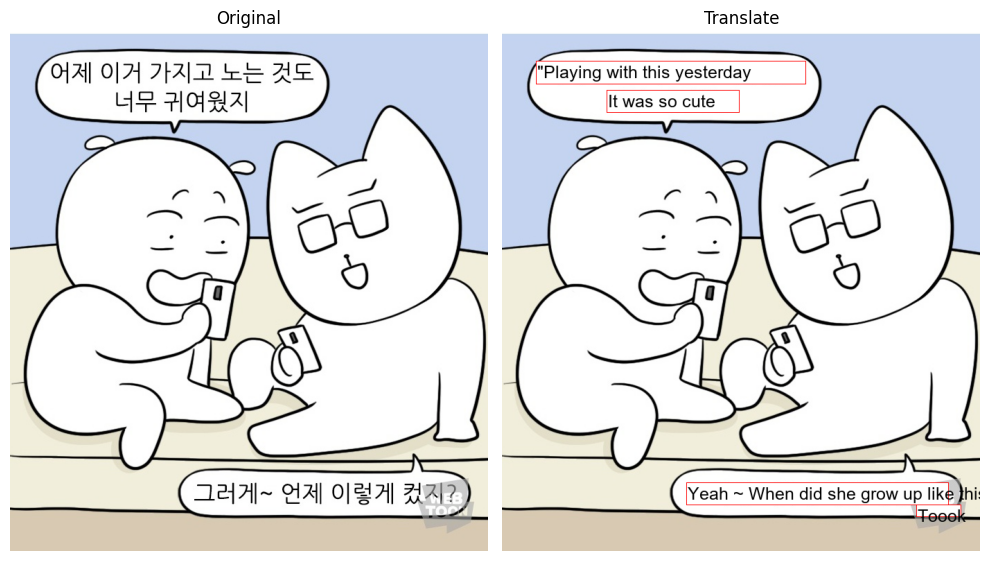

In [16]:
# ── 4. 이미지에 합성 ─────────────────────────────────────────────────
from PIL import ImageFont

FONT_PATH = 'C:/Windows/Fonts/Arial.ttf'
FONT_SIZE = 25
font = ImageFont.truetype(FONT_PATH, FONT_SIZE)

image_translated = image.copy()
draw = ImageDraw.Draw(image_translated)

for item in chunk_data:
    x1, y1, x2, y2 = item['box']
    draw.rectangle([x1, y1, x2, y2], fill='white', outline='red')
    draw.text((x1 + 2, y1 + 2), item['translate'], font=font, fill='black')

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes[0].imshow(image)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(image_translated)
axes[1].set_title('Translate')
axes[1].axis('off')

plt.tight_layout()
plt.show()
